# Econ 390 - Lecture 13: Matplotlib Line Plots
Today we will begin learning how to create plots in Python using Matplotlib. You can find the relevant textbook chapters for [McKinney](https://wesmckinney.com/book/plotting-and-visualization) and [Turrell](https://aeturrell.github.io/coding-for-economists/vis-matplotlib.html#understanding-matplotlib).

## Mid-Semester Course Evaluation
Tomorrow is the final day to complete the mid-semester course evaluation! Completing the survey will give me active feedback to improve your experience in the class and will help me out a ton moving forward. Look for an email from `learningassessment@provost.wisc.edu` or head to [this](https://heliocampusac.wisc.edu/index.cfm/page/AefisDashboard.home?Login=1) link and look for the Econ 390 - 001 course survey. Thank you! 

## Essay Competition
There is an [Undergraduate Essay Competition](https://csld.wisc.edu/2026/02/27/announcing-the-2026-undergraduate-essay-competition/) being run by the Center for the Study of Liberal Democracy here at UW Madison. ~1000 word essays due on March 30th.

## Data

In [3]:
# Load Exchange Rate Data into a DataFrame
url = "https://m-mcmain.github.io/files/Econ390SP26/"
USD_ER = pd.read_csv(url + "USD_ERs.csv", index_col = 0)
USD_ER = USD_ER.rename(columns={"DEXUSEU_NBD20060101":"USD_EU", "DEXCHUS_NBD20060101":"CHY_USD", "DTWEXBGS_NBD20060101":"Broad USD"})
USD_ER

,Broad USD,CHY_USD,USD_EU
observation_date,,,
1/1/2006,100.00000,100.00000,100.00000
2/1/2006,100.21117,99.82489,98.46800
3/1/2006,100.42808,99.62384,99.19950
4/1/2006,99.74348,99.36736,101.21851
5/1/2006,97.51177,99.35193,105.29425
...,...,...,...
7/1/2025,120.52656,88.94931,96.25020
8/1/2025,120.98444,88.93206,96.05770
9/1/2025,120.45339,88.32157,96.81015


## Intro to Matplotlib

In [4]:
# New imports
import pandas as pd, matplotlib.pyplot as plt

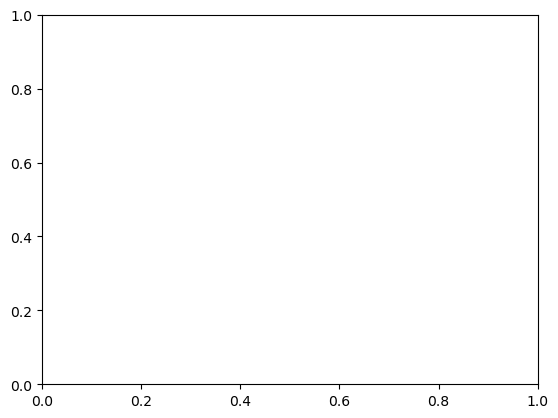

In [12]:
# Defining your first plot
fig, ax = plt.subplots()

In [6]:
# What types are these new objects?
print(type(fig))
print(type(ax))

<class 'matplotlib.figure.Figure'>
<class 'matplotlib.axes._axes.Axes'>


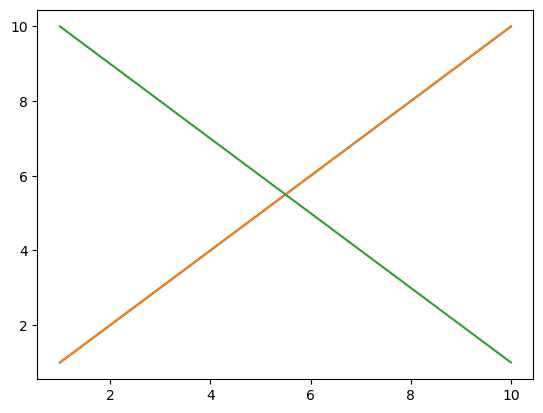

In [14]:
# Using plot to make lines
ax.plot([1,10],[1,10])
ax.plot([1,10],[10,1])
fig

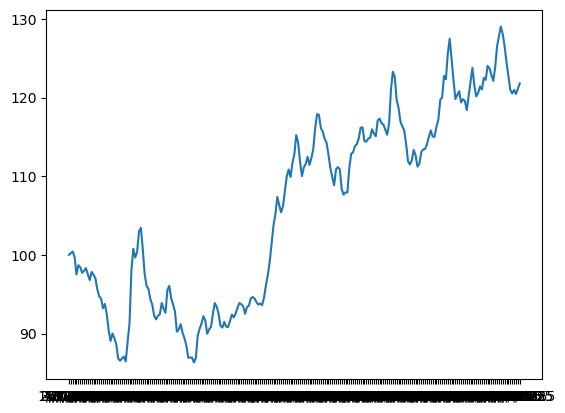

In [17]:
# Plotting from our DataFrame
fig, ax = plt.subplots()

ax.plot(USD_ER.index, USD_ER["Broad USD"]);

In [20]:
# ANOTHER new package
from datetime import datetime

# New option to read_csv
USD_ER = pd.read_csv(url + "USD_ERs.csv", index_col=0, parse_dates=True)
USD_ER = USD_ER.rename(columns={"DEXUSEU_NBD20060101":"USD_EU", "DEXCHUS_NBD20060101":"CHY_USD", "DTWEXBGS_NBD20060101":"Broad USD"})
USD_ER

,Broad USD,CHY_USD,USD_EU
observation_date,,,
2006-01-01,100.00000,100.00000,100.00000
2006-02-01,100.21117,99.82489,98.46800
2006-03-01,100.42808,99.62384,99.19950
2006-04-01,99.74348,99.36736,101.21851
2006-05-01,97.51177,99.35193,105.29425
...,...,...,...
2025-07-01,120.52656,88.94931,96.25020
2025-08-01,120.98444,88.93206,96.05770
2025-09-01,120.45339,88.32157,96.81015


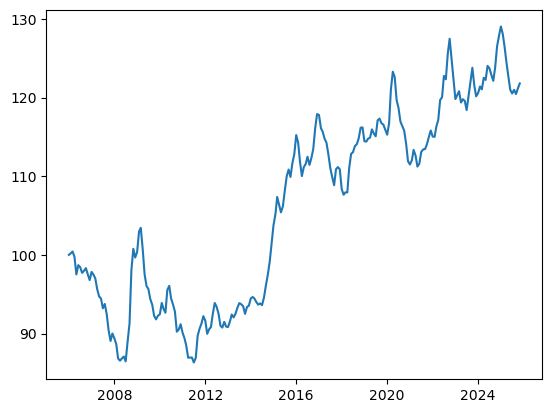

In [21]:
# Try it now
# Plotting from our DataFrame
fig, ax = plt.subplots()

ax.plot(USD_ER.index, USD_ER["Broad USD"]);

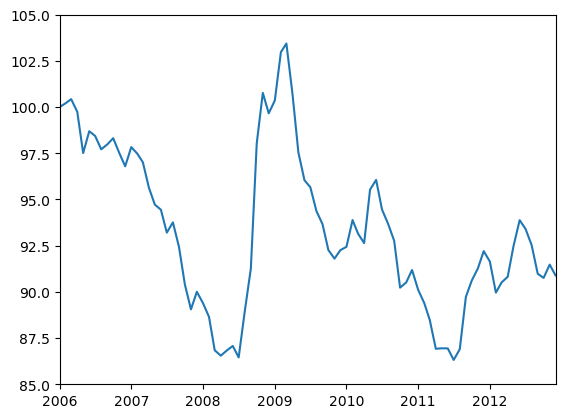

In [24]:
# Set limits on the axes
ax.set_xlim([datetime(2006,1,1),datetime(2012,12,1)])
ax.set_ylim([85,105])
fig

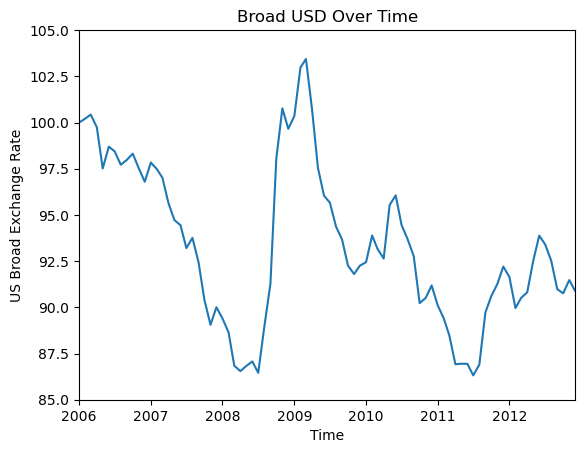

In [26]:
# Just do it all in one line
fig, ax = plt.subplots()

ax.plot(USD_ER.index, USD_ER["Broad USD"]);

ax.set(xlim = (datetime(2006,1,1),datetime(2012,12,1)), ylim = (85,105), title = "Broad USD Over Time", xlabel = "Time", ylabel = "US Broad Exchange Rate");

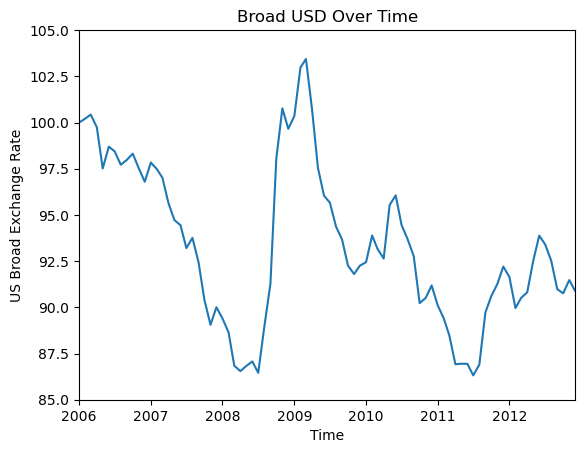

In [27]:
# When that one line gets really long you can make it more readable
fig, ax = plt.subplots()

ax.plot(USD_ER.index, USD_ER["Broad USD"]);

ax.set(xlim = (datetime(2006,1,1), datetime(2012,12,1)), 
       ylim = (85,105), 
       title = "Broad USD Over Time", 
       xlabel = "Time", 
       ylabel = "US Broad Exchange Rate");

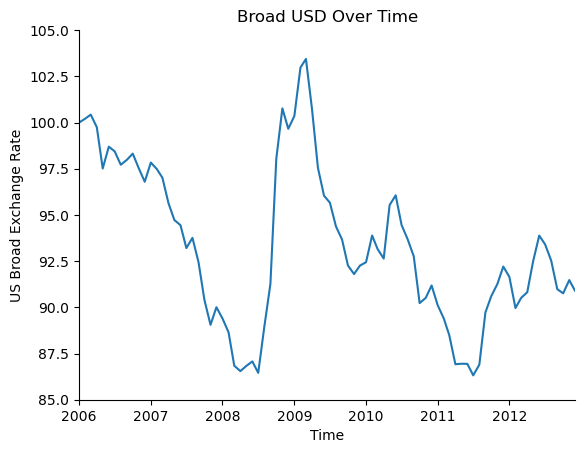

In [30]:
# Options
ax.spines[['top','right']].set_visible(False)
fig

## Practice - Line Plots
1. Is there a better way to deal with the axes? What is a way to do it to not manually change xlim and ylim?
2. Copy and paste the previous plot below and add the line for the Chinese Yuan RMB to USD. If you did the previous part right, you still shouldn't need to manually update xlim and ylim!
3. Modify the code to change the color of the Chinese Yuan RMB to USD line.
4. Modify your code and add the argument alpha=0.3 as a line style option for the Chinese Yuan RMB to USD line. What does this change?
5. Modify the code to make one of the lines dashed. Or try out `linestyle = '--'` `linestyle = '-.'` `linestyle = ':'`
6. With all of these changes, how do you feel about the plot? Any concerns?

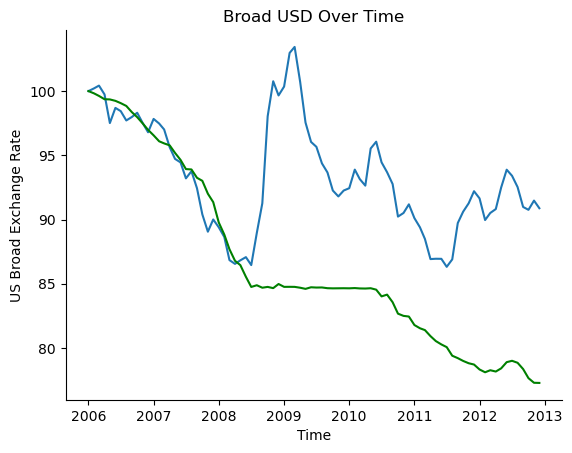

In [48]:
# Results:
fig, ax = plt.subplots()

# 1.
USD_ER = USD_ER.loc[USD_ER.index < datetime(2013,1,1),:]
# 2-6.
ax.plot(USD_ER.index, USD_ER["Broad USD"])
ax.plot(USD_ER.index, USD_ER["CHY_USD"], color = "Green", linestyle = "-")

ax.set(title = "Broad USD Over Time", 
       xlabel = "Time", 
       ylabel = "US Broad Exchange Rate");

ax.spines[['top','right']].set_visible(False)

## Line Plots with Multiple Lines

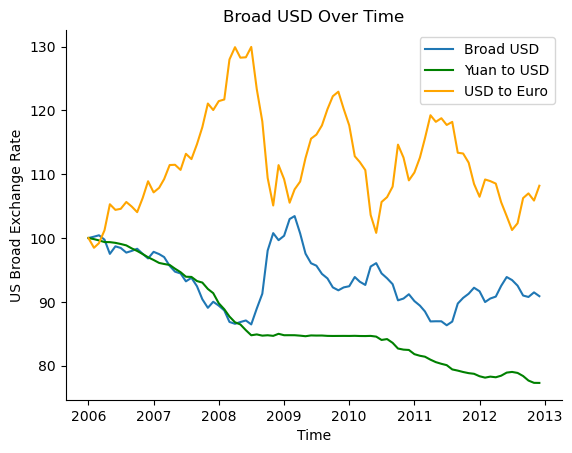

In [52]:
# Multiple lines?
fig, ax = plt.subplots()

USD_ER = USD_ER.loc[USD_ER.index < datetime(2013,1,1),:]

ax.plot(USD_ER.index, USD_ER["Broad USD"], label = "Broad USD")
ax.plot(USD_ER.index, USD_ER["CHY_USD"], color = "Green", linestyle = "-", label = "Yuan to USD")
ax.plot(USD_ER.index, USD_ER["USD_EU"], color = "Orange", linestyle = "-", label = "USD to Euro")

ax.set(title = "Broad USD Over Time", 
       xlabel = "Time", 
       ylabel = "US Broad Exchange Rate");

ax.spines[['top','right']].set_visible(False)
ax.legend();

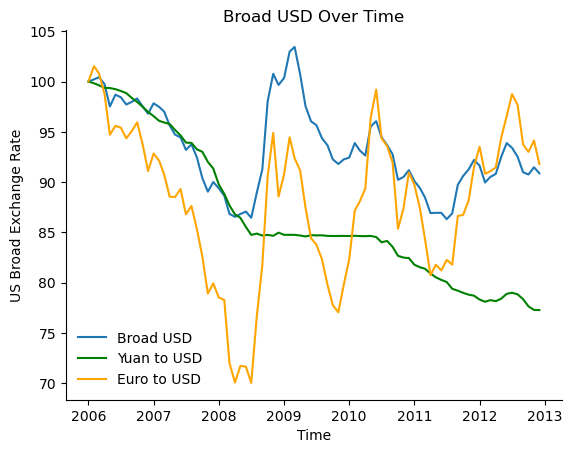

In [56]:
# Let's fix one of these
fig, ax = plt.subplots()

USD_ER["EU_USD"] = 100 + (100-USD_ER['USD_EU'])

USD_ER = USD_ER.loc[USD_ER.index < datetime(2013,1,1),:]

ax.plot(USD_ER.index, USD_ER["Broad USD"], label = "Broad USD")
ax.plot(USD_ER.index, USD_ER["CHY_USD"], color = "Green", linestyle = "-", label = "Yuan to USD")
ax.plot(USD_ER.index, USD_ER["EU_USD"], color = "Orange", linestyle = "-", label = "Euro to USD")

ax.set(title = "Broad USD Over Time", 
       xlabel = "Time", 
       ylabel = "US Broad Exchange Rate");

ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False);

Text(2010-05-01 00:00:00, 100, 'USD to Euro')

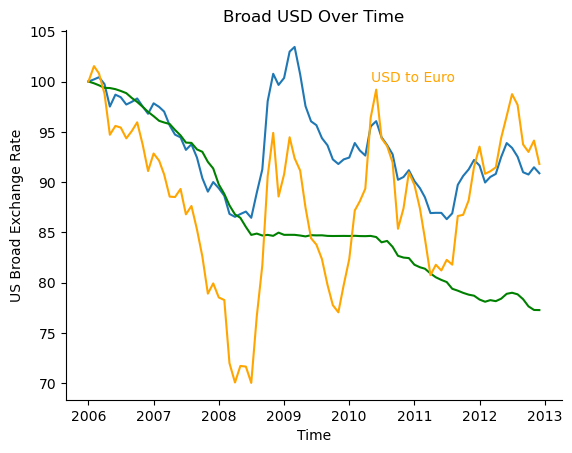

In [58]:
# Manually include text
fig, ax = plt.subplots()

USD_ER["EU_USD"] = 100 + (100-USD_ER['USD_EU'])

USD_ER = USD_ER.loc[USD_ER.index < datetime(2013,1,1),:]

ax.plot(USD_ER.index, USD_ER["Broad USD"], label = "Broad USD")
ax.plot(USD_ER.index, USD_ER["CHY_USD"], color = "Green", linestyle = "-", label = "Yuan to USD")
ax.plot(USD_ER.index, USD_ER["EU_USD"], color = "Orange", linestyle = "-", label = "Euro to USD")

ax.set(title = "Broad USD Over Time", 
       xlabel = "Time", 
       ylabel = "US Broad Exchange Rate");

ax.spines[['top','right']].set_visible(False)
ax.text(datetime(2010,5,1), 100, "USD to Euro", color = "Orange")

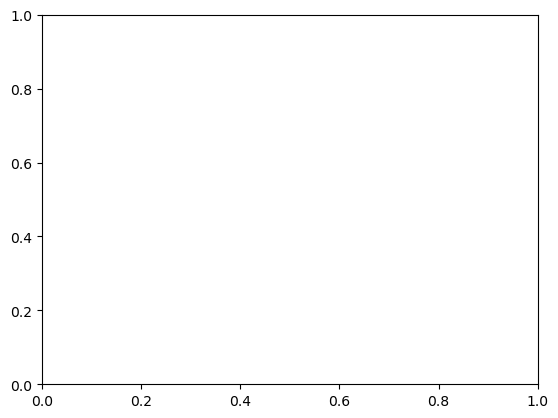

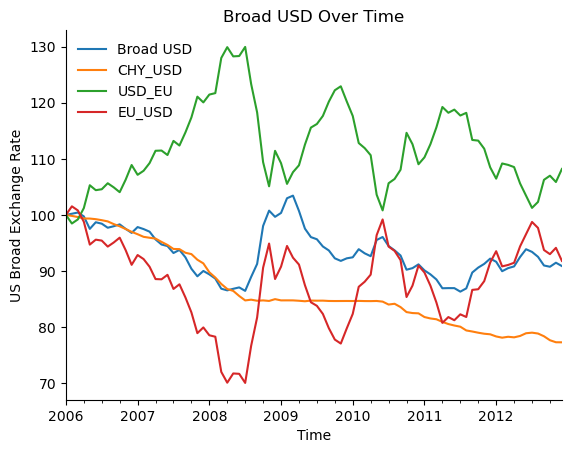

In [59]:
# Plot alone works, but it makes assumptions about what you want!
fig, ax = plt.subplots()

ax = USD_ER.plot()

ax.set(title = "Broad USD Over Time", 
       xlabel = "Time", 
       ylabel = "US Broad Exchange Rate");

ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False)
plt.show()

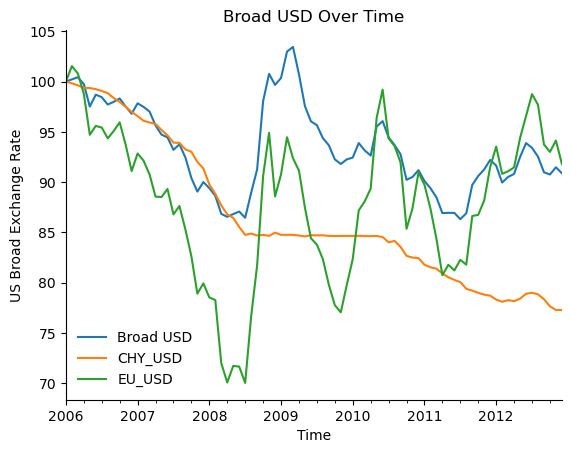

In [61]:
# Let's drop the USD to EU ER and go again
USD_ER = USD_ER.drop("USD_EU", axis=1)

ax = USD_ER.plot()

ax.set(title = "Broad USD Over Time", 
       xlabel = "Time", 
       ylabel = "US Broad Exchange Rate");

ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False)
plt.show()

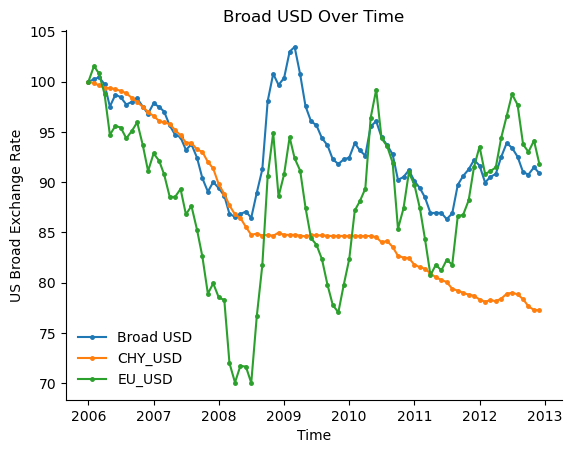

In [63]:
# If you want to have similar styles for many different lines, you can loop through them
fig, ax = plt.subplots()

for ER in USD_ER.columns:
    ax.plot(USD_ER.index,
            USD_ER[ER],
            label = ER,
            marker = ".",
            markersize = 5)

ax.set(title = "Broad USD Over Time", 
       xlabel = "Time", 
       ylabel = "US Broad Exchange Rate");

ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False)
plt.show()